# 01. Metric Panels

Illustrative panels of the three functional metrics of the excitable cell-cell circuit (Fig. 6B to 6D): how the pulse amplitude, the threshold for activation and the refractory period respond to changes in single parameters.

The circuit is

$$\frac{dX}{dt} = X\left[aX\left(1-\frac{X}{c}\right) - bY - d\right], \qquad \frac{dY}{dt} = Y\left[fX - g\right]$$

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add package source to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# DynamicModel_Package lives in the repository's libs/ directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'libs')))

FIGURE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../figures'))
RESULT_DIR = os.path.abspath(os.path.join(os.getcwd(), '../data/results'))
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

from circuit_to_target.model import integrate, to_dynamic_model
from circuit_to_target.metrics import threshold

## Cross-check the integrator

`integrate()` reimplements `DynamicModel.euler_integrate_keep_positive` on NumPy arrays for speed. The two must agree exactly.

In [2]:
pars = {'a': 1.0, 'b': 1.0, 'c': 100.0, 'd': 1.0, 'f': 1.0, 'g': 1.0}

own = integrate(10.0, 2.0, pars, 0.2, dt=1e-3)
ref = to_dynamic_model(pars).euler_integrate_keep_positive(
    {'x': 10.0, 'y': 2.0, 't': 0}, 0.2, 1e-3)

n = min(len(own), len(ref))
dx = np.abs(np.asarray(ref['x'][:n], float) - own['x'].values[:n]).max()
dy = np.abs(np.asarray(ref['y'][:n], float) - own['y'].values[:n]).max()
print(f"max |dx| = {dx:.3e}")
print(f"max |dy| = {dy:.3e}")
assert dx == 0 and dy == 0, "integrate() disagrees with DynamicModel2D"
print("integrate() agrees with DynamicModel2D")

max |dx| = 0.000e+00
max |dy| = 0.000e+00
integrate() agrees with DynamicModel2D


/Users/yaelleb/.pyenv/versions/3.11.3/lib/python3.11/site-packages/DynamicModel_Package/ModelBase.py:97: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df,variables_initial_df],ignore_index=True)


## Fig. 6B - pulse amplitude

Increasing the autocrine strength `a` (or the carrying capacity `c`, or decreasing the removal rate `d`) gives a stronger pulse.

a = 1: peak X = 25.78
a = 5: peak X = 98.20


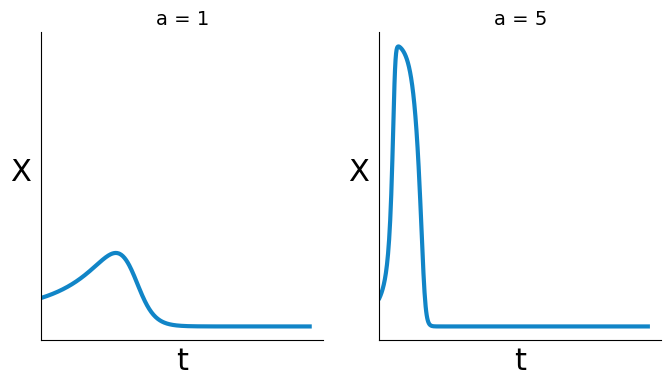

In [3]:
def style_time_axis(ax, ylabel):
    ax.set_xlim(left=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
    ax.set_xlabel('t', fontsize=22)
    ax.set_ylabel(ylabel, fontsize=22, rotation=0, labelpad=15)


base = {'a': 1.0, 'b': 1.0, 'c': 100.0, 'd': 1.0, 'f': 1.0, 'g': 1.0}
fig, axs = plt.subplots(ncols=2, figsize=(8, 4), sharey=True)

for ax, a_value in zip(axs, [1.0, 5.0]):
    pars = dict(base, a=a_value)
    traj = integrate(10.0, 2.0, pars, 0.5, dt=1e-3)
    ax.plot(traj['t'], traj['x'], lw=3, c='#1185c7')
    ax.set_title(f'a = {a_value:g}', fontsize=14)
    style_time_axis(ax, 'X')
    print(f"a = {a_value:g}: peak X = {traj['x'].max():.2f}")

fig.savefig(os.path.join(FIGURE_DIR, 'pulse_amplitude.png'), dpi=600, bbox_inches='tight')
fig.savefig(os.path.join(FIGURE_DIR, 'pulse_amplitude.pdf'), dpi=600, bbox_inches='tight')

## Fig. 6C - threshold for activation

Two initial conditions per panel. With `c = 20` and `d = 1`, `a = 0.1` gives $ac < 4d$: the X nullcline never reaches the first quadrant, there is no finite threshold and no input can excite a pulse. This is the monostable "OFF" regime of Fig. 6F ($p_1 = ca/d = 2 < 4$). At `a = 3` ($p_1 = 60$) a finite threshold exists, and only the initial condition above it fires.

a = 0.1: p1 = 2, threshold = nan
a = 3: p1 = 60, threshold = 0.3391


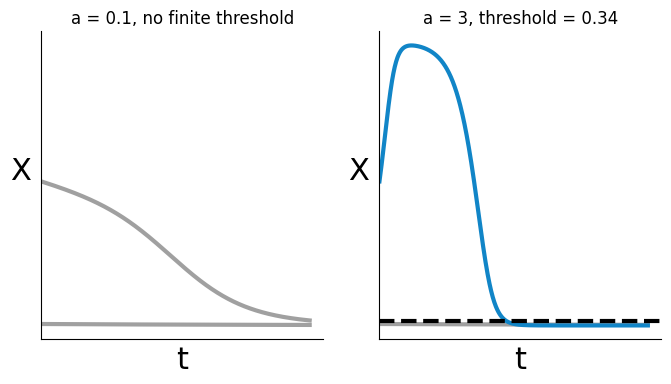

In [4]:
base = {'a': 1.0, 'b': 1.0, 'c': 20.0, 'd': 1.0, 'f': 1.0, 'g': 1.0}
x_inits = [0.1, 10.0]

fig, axs = plt.subplots(ncols=2, figsize=(8, 4), sharey=True)

for ax, a_value in zip(axs, [0.1, 3.0]):
    pars = dict(base, a=a_value)
    x_threshold = threshold(pars['a'], pars['c'], pars['d'])
    p1 = pars['c'] * pars['a'] / pars['d']

    for i, x0 in enumerate(x_inits):
        traj = integrate(x0, 0.1, pars, 1.0, dt=1e-3)
        fires = np.isfinite(x_threshold) and x0 > x_threshold
        ax.plot(traj['t'], traj['x'], lw=3, zorder=i,
                color='#1185c7' if fires else '#a0a0a0')

    if np.isfinite(x_threshold):
        ax.axhline(x_threshold, ls='--', color='black', lw=3, zorder=2)
        label = f'a = {a_value:g}, threshold = {x_threshold:.2f}'
    else:
        label = f'a = {a_value:g}, no finite threshold'
    ax.set_title(label, fontsize=12)
    style_time_axis(ax, 'X')
    print(f"a = {a_value:g}: p1 = {p1:g}, threshold = {x_threshold:.4f}")

fig.savefig(os.path.join(FIGURE_DIR, 'threshold_to_activation.png'), dpi=600, bbox_inches='tight')
fig.savefig(os.path.join(FIGURE_DIR, 'threshold_to_activation.pdf'), dpi=600, bbox_inches='tight')

## Fig. 6D - refractory period

Increasing the inhibitor turnover `g` shortens the time during which `Y` stays elevated, and so shortens the refractory period.

g = 1: refractory period = 4.821
g = 10: refractory period = 0.682


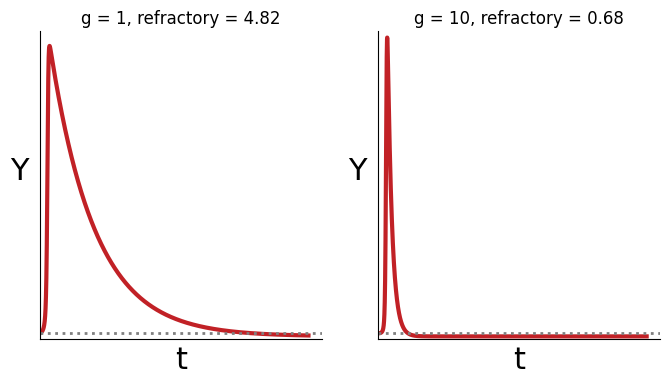

In [5]:
from circuit_to_target.metrics import refractory_period

base = {'a': 1.0, 'b': 1.0, 'c': 100.0, 'd': 1.0, 'f': 1.0, 'g': 1.0}
fig, axs = plt.subplots(ncols=2, figsize=(8, 4), sharey=True)

for ax, g_value in zip(axs, [1.0, 10.0]):
    pars = dict(base, g=g_value)
    traj = integrate(10.0, 1.0, pars, 6.0, dt=1e-3)
    ax.plot(traj['t'], traj['y'], color='#c12126', lw=3)

    cutoff = traj['y'].max() * 0.01
    ax.axhline(cutoff, ls=':', color='grey', lw=2)
    style_time_axis(ax, 'Y')
    ax.set_ylim(bottom=-1)
    ax.set_title(f'g = {g_value:g}, refractory = {refractory_period(pars):.2f}', fontsize=12)
    print(f"g = {g_value:g}: refractory period = {refractory_period(pars):.3f}")

fig.savefig(os.path.join(FIGURE_DIR, 'refractory_period.png'), dpi=600, bbox_inches='tight')
fig.savefig(os.path.join(FIGURE_DIR, 'refractory_period.pdf'), dpi=600, bbox_inches='tight')